In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import cupy as cp
import seaborn as sns
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB



In [2]:
def drop_unperturb_trials_modified(td_tr_, dstrb_idx, thresh_val = -2.5):
    td_tr = td_tr_.copy()
    disturb_mean_vals_s = td_tr['disturb_mean'].values

    threshold_s = -scipy.stats.sem(disturb_mean_vals_s)
    disturb_mean_sorted_s = disturb_mean_vals_s[dstrb_idx]
    idx_to_keep_s = int(np.searchsorted(disturb_mean_sorted_s, threshold_s))

    # Original selected trials
    selected_by_threshold = np.zeros(len(td_tr), dtype=bool)
    selected_by_threshold[dstrb_idx[:idx_to_keep_s]] = True

    # Additional trials with disturb_mean > -2
    selected_by_value = disturb_mean_vals_s > thresh_val

    # Keep trials satisfying either condition
    final_mask = selected_by_threshold & selected_by_value

    print(
        f"  threshold = {threshold_s:.3f}  |  "
        f"trials selected by threshold: {idx_to_keep_s}  |  "
        f"total trials kept: {final_mask.sum()}"
    )

    td_tr = td_tr.iloc[np.where(final_mask)[0]]
    return td_tr

In [3]:
session = 'M061_2025_03_06_14_00'
data_dir='/data/bnd-data/raw/'


In [4]:
df_tr, dstrb_idx = dsp.load_and_process_session(session, data_dir)
df_design_s = drop_unperturb_trials_modified(df_tr, dstrb_idx, thresh_val=-2)
perturb_td_s = pyal.restrict_to_interval(
            df_design_s, start_point_name='idx_sol_on', rel_start=-200, rel_end=300
        )

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']


Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


Skipped 40 trials
Otsu immobility threshold: 2.9536
Dropped 48 of 333 rows (14.41%).
  threshold = -0.031  |  trials selected by threshold: 220  |  total trials kept: 217


In [5]:
# Use the sliced matrix already made (perturb_td_s)
# perturb_td_s covers idx_sol_on -200 to +300 bins

area = 'MOp'
spikes_col = f'{area}_rates'

# Stack: (n_trials, n_bins, n_neurons)
X = np.stack(perturb_td_s[spikes_col].values)
dirs = perturb_td_s['values_Sol_direction'].values

print(f'X shape: {X.shape}  (trials x bins x neurons)')
print(f'Unique directions: {np.unique(dirs)}')

X shape: (217, 501, 178)  (trials x bins x neurons)
Unique directions: [0 1 2 3 4 5 6 7 8 9 10 11]


In [6]:
# Mean firing rate per trial -> (n_trials, n_neurons)
bin_size = perturb_td_s['bin_size'].values[0]
X_mean = X.mean(axis=1) / bin_size  # Hz

# Mean per direction -> (n_dirs, n_neurons)
unique_dirs = np.unique(dirs)
tuning = np.stack([X_mean[dirs == d].mean(axis=0) for d in unique_dirs])
angles = np.array([Params.sol_dir_to_angle[d] for d in unique_dirs])

print(f'Tuning matrix shape: {tuning.shape}  (directions x neurons)')
print(f'Angles: {angles}')

Tuning matrix shape: (12, 178)  (directions x neurons)
Angles: [150 210 330  30  90 150 210 270 330  30  90 270]


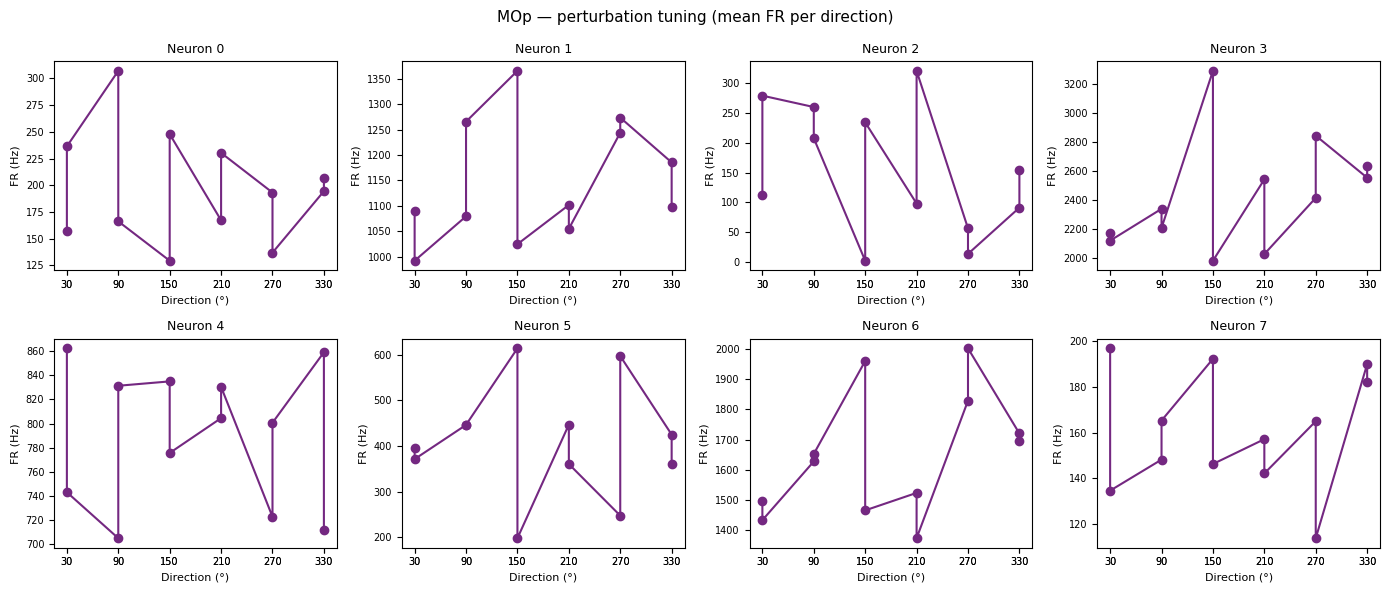

In [7]:
# Plot tuning curves for 8 example neurons
sort_idx = np.argsort(angles)
angles_sorted = angles[sort_idx]
tuning_sorted = tuning[sort_idx]

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=False)
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.plot(angles_sorted, tuning_sorted[:, i], 'o-', color=getattr(colors, area))
    ax.set_title(f'Neuron {i}', fontsize=9)
    ax.set_xlabel('Direction (°)', fontsize=8)
    ax.set_ylabel('FR (Hz)', fontsize=8)
    ax.set_xticks(angles_sorted)
    ax.tick_params(labelsize=7)

fig.suptitle(f'{area} — perturbation tuning (mean FR per direction)', fontsize=11)
plt.tight_layout()
plt.show()

## Fraction of MOp neurons responsive to any perturbation
Baseline vs response window, Wilcoxon signed-rank + FDR correction.

In [8]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# perturb_td_s was sliced at rel_start=-200, rel_end=300 (10ms bins)
# so idx_sol_on lands at bin 200 within X
SOL_ON_BIN = 200

# Baseline: -0.6 to -0.1 s  ->  bins 140:190  (50 bins)
# Response:  0.0 to +0.5 s  ->  bins 200:250  (50 bins)
baseline = X[:, SOL_ON_BIN - 60 : SOL_ON_BIN - 10, :]  # (n_trials, 50 bins, n_neurons)
response = X[:, SOL_ON_BIN     : SOL_ON_BIN + 50,  :]  # (n_trials, 50 bins, n_neurons)

# Mean FR per trial -> (n_trials, n_neurons)
baseline_mean = baseline.mean(axis=1) / bin_size
response_mean = response.mean(axis=1) / bin_size

print(f'baseline window shape: {baseline_mean.shape}')
print(f'response window shape: {response_mean.shape}')

baseline window shape: (217, 178)
response window shape: (217, 178)


In [9]:
n_neurons = baseline_mean.shape[1]

p_values = np.array([
    wilcoxon(baseline_mean[:, i], response_mean[:, i]).pvalue
    for i in range(n_neurons)
])

reject, p_fdr, _, _ = multipletests(p_values, method='fdr_bh', alpha=0.05)

n_responsive = reject.sum()
fraction = reject.mean()
print(f'{area}: {n_responsive}/{n_neurons} neurons responsive ({fraction:.1%})')

MOp: 141/178 neurons responsive (79.2%)


## Population visualizations — MOp response to perturbation

In [10]:
# Trial-averaged firing rate over time for every neuron: (n_neurons, n_bins)
X_tavg = X.mean(axis=0).T / bin_size  # (n_neurons, n_bins)

time_bins = (np.arange(X.shape[1]) - SOL_ON_BIN) * bin_size  # seconds relative to sol_on

responsive_idx    = np.where(reject)[0]
nonresponsive_idx = np.where(~reject)[0]

print(f'n responsive: {len(responsive_idx)}, n non-responsive: {len(nonresponsive_idx)}')

n responsive: 141, n non-responsive: 37


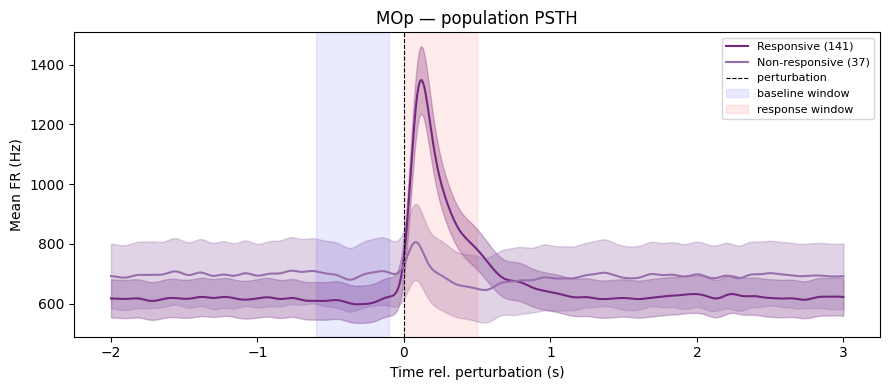

In [11]:
# Mean population PSTH: responsive vs non-responsive
fig, ax = plt.subplots(figsize=(9, 4))

for idx, label, color in [
    (responsive_idx,    f'Responsive ({len(responsive_idx)})',    getattr(colors, area)),
    (nonresponsive_idx, f'Non-responsive ({len(nonresponsive_idx)})', getattr(colors, f'{area}_light')),
]:
    if len(idx) == 0:
        continue
    mean_fr = X_tavg[idx].mean(axis=0)
    sem_fr  = scipy.stats.sem(X_tavg[idx], axis=0)
    ax.fill_between(time_bins, mean_fr - sem_fr, mean_fr + sem_fr, alpha=0.3, color=color)
    ax.plot(time_bins, mean_fr, color=color, label=label)

ax.axvline(0, color='k', linestyle='--', linewidth=0.8, label='perturbation')
ax.axvspan(-0.6, -0.1, alpha=0.08, color='blue', label='baseline window')
ax.axvspan(0,    0.5,  alpha=0.08, color='red',  label='response window')
ax.set_xlabel('Time rel. perturbation (s)')
ax.set_ylabel('Mean FR (Hz)')
ax.set_title(f'{area} — population PSTH')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

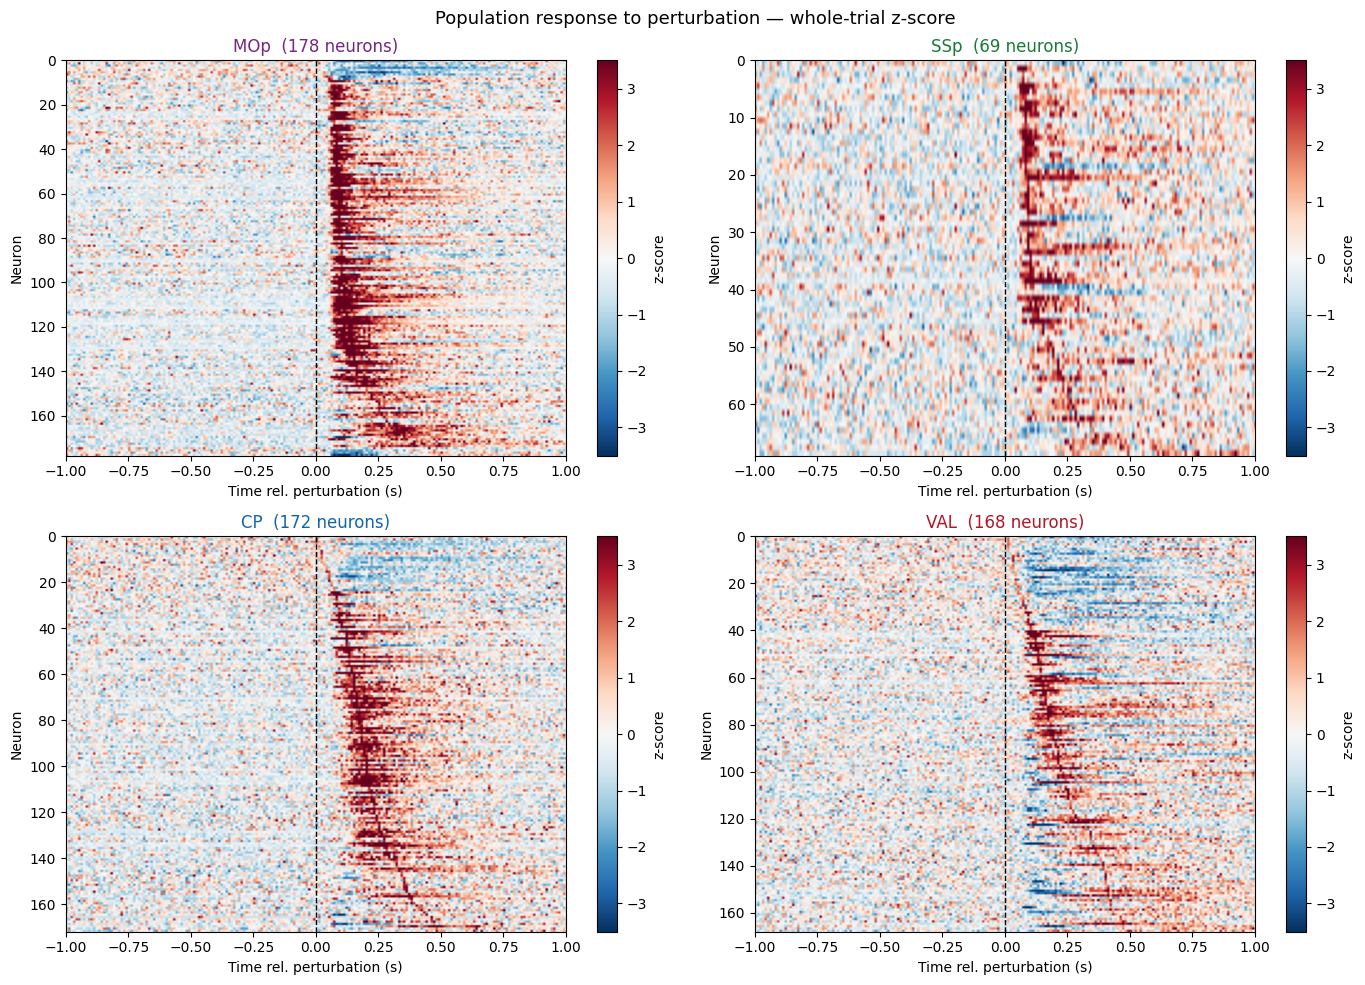

In [12]:
resp_bins = slice(SOL_ON_BIN, SOL_ON_BIN + 50)  # 0 to 0.5s

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, a in zip(axes.flatten(), Params.areas):
    X_a = np.stack(perturb_td_s[f'{a}_spikes'].values)  # (n_trials, n_bins, n_neurons)
    X_tavg_a = X_a.mean(axis=0).T / bin_size            # (n_neurons, n_bins)

    X_z = (X_tavg_a - X_tavg_a.mean(axis=1, keepdims=True)) / (X_tavg_a.std(axis=1, keepdims=True) + 1e-6)
    sort_order = np.argsort(X_z[:, resp_bins].argmax(axis=1))

    im = ax.imshow(
        X_z[sort_order],
        aspect='auto',
        cmap='RdBu_r',
        vmin=-3.5, vmax=3.5,
        extent=[time_bins[0], time_bins[-1], len(sort_order), 0]
    )
    ax.axvline(0, color='k', linewidth=1, linestyle='--')
    # ax.axvspan(-0.6, -0.1, alpha=0.15, color='blue')
    # ax.axvspan(0,    0.5,  alpha=0.15, color='red')
    ax.set_xlabel('Time rel. perturbation (s)')
    ax.set_ylabel('Neuron')
    ax.set_xlim(-1, 1)
    ax.set_title(f'{a}  ({X_tavg_a.shape[0]} neurons)', color=getattr(colors, a))
    plt.colorbar(im, ax=ax, label='z-score')

plt.suptitle('Population response to perturbation — whole-trial z-score', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

SOL_ON_BIN = 200
bin_size = perturb_td_s['bin_size'].values[0]
area_results = {}

for a in Params.areas:
    X_a = np.stack(perturb_td_s[f'{a}_spikes'].values)  # (n_trials, n_bins, n_neurons)

    bl   = X_a[:, SOL_ON_BIN - 60 : SOL_ON_BIN - 10, :].mean(axis=1) / bin_size
    resp = X_a[:, SOL_ON_BIN      : SOL_ON_BIN + 50,  :].mean(axis=1) / bin_size

    n_neurons = bl.shape[1]
    p_values = np.array([
        wilcoxon(bl[:, i], resp[:, i]).pvalue
        for i in range(n_neurons)
    ])

    reject, _, _, _ = multipletests(p_values, method='fdr_bh', alpha=0.05)

    n_resp = reject.sum()
    fraction = n_resp / n_neurons
    ci_low, ci_high = proportion_confint(n_resp, n_neurons, alpha=0.05, method='wilson')

    area_results[a] = dict(n_neurons=n_neurons, n_resp=n_resp,
                           fraction=fraction, ci_low=ci_low, ci_high=ci_high)

    print(f'{a:4s}: {n_resp}/{n_neurons} ({fraction:.1%})  95% CI [{ci_low:.1%}, {ci_high:.1%}]')

MOp : 141/178 (79.2%)  95% CI [72.7%, 84.5%]
SSp : 51/69 (73.9%)  95% CI [62.5%, 82.8%]


CP  : 127/172 (73.8%)  95% CI [66.8%, 79.8%]
VAL : 98/168 (58.3%)  95% CI [50.8%, 65.5%]


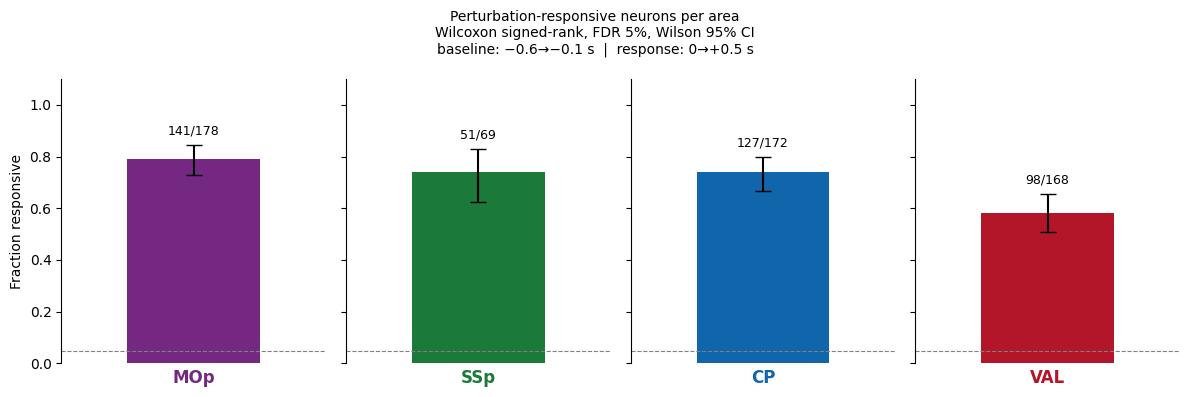

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4), sharey=True)

for ax, a in zip(axes, Params.areas):
    r = area_results[a]
    color = getattr(colors, a)

    err_low  = r['fraction'] - r['ci_low']
    err_high = r['ci_high'] - r['fraction']

    ax.bar(0, r['fraction'], color=color, width=0.6, zorder=2)
    ax.errorbar(0, r['fraction'], yerr=[[err_low], [err_high]],
                fmt='none', color='k', capsize=6, linewidth=1.5, zorder=3)
    ax.text(0, r['fraction'] + err_high + 0.03,
            f"{r['n_resp']}/{r['n_neurons']}",
            ha='center', va='bottom', fontsize=9)

    ax.set_xlim(-0.6, 0.6)
    ax.set_xticks([])
    ax.set_xlabel(a, fontsize=12, color=color, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.axhline(0.05, color='gray', linestyle='--', linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

axes[0].set_ylabel('Fraction responsive')
fig.suptitle('Perturbation-responsive neurons per area\n'
             'Wilcoxon signed-rank, FDR 5%, Wilson 95% CI\n'
             'baseline: −0.6→−0.1 s  |  response: 0→+0.5 s', fontsize=10)
plt.tight_layout()
plt.show()

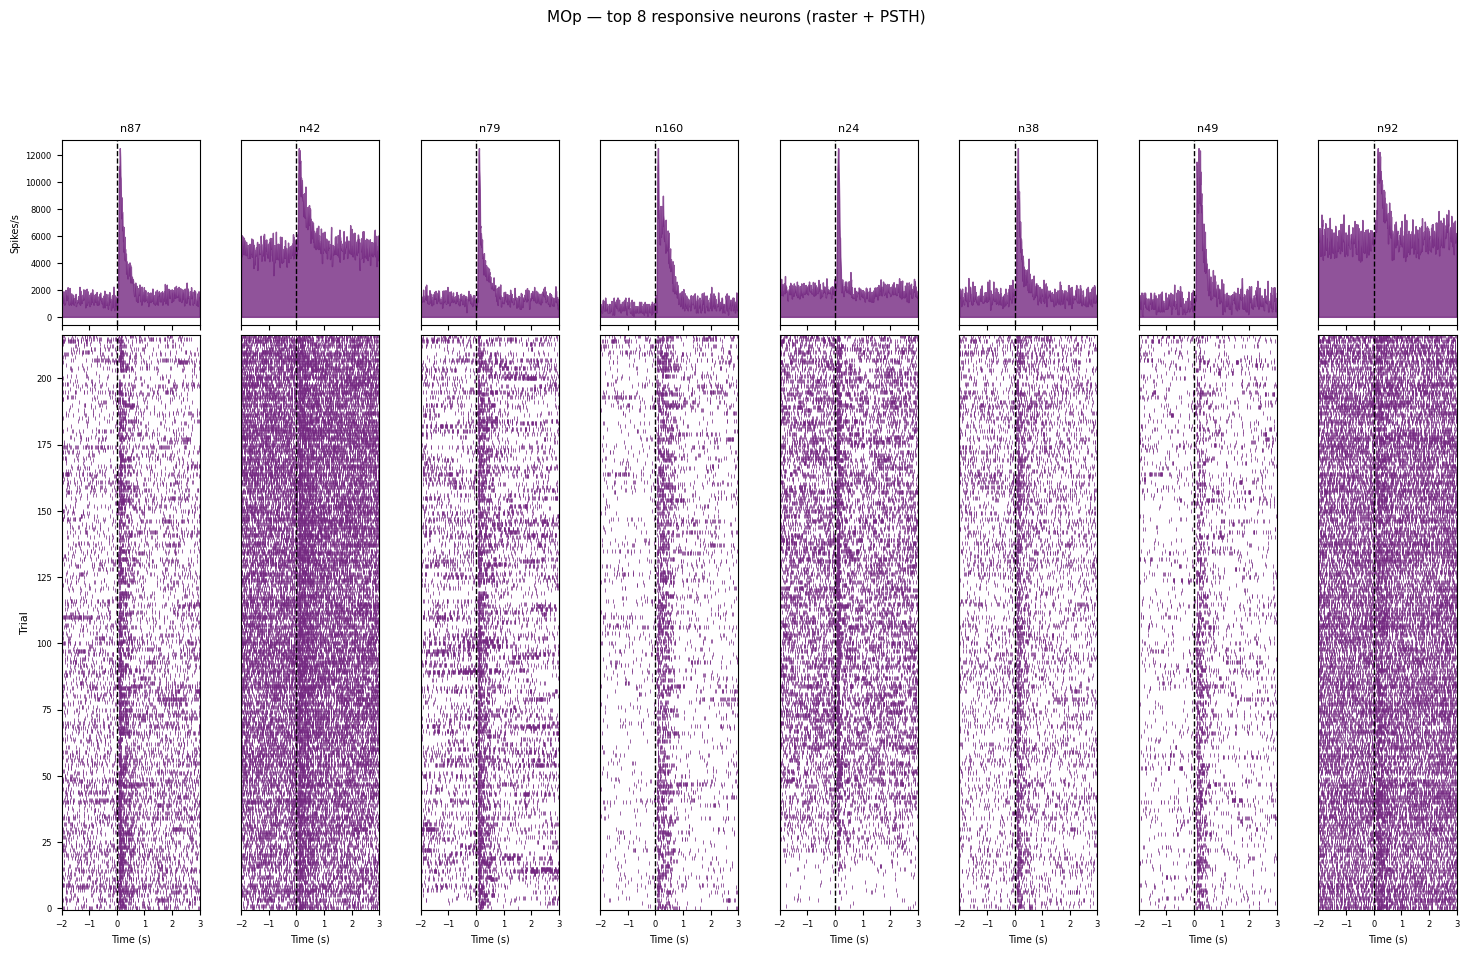

In [15]:
# Pick 8 responsive MOp neurons with strongest mean response
X_mop = np.stack(perturb_td_s['MOp_spikes'].values)  # (n_trials, n_bins, n_neurons)
time_bins = (np.arange(X_mop.shape[1]) - SOL_ON_BIN) * bin_size

resp_mean = X_mop[:, SOL_ON_BIN:SOL_ON_BIN+50, :].mean(axis=(0,1))
bl_mean_n = X_mop[:, SOL_ON_BIN-60:SOL_ON_BIN-10, :].mean(axis=(0,1))
response_strength = resp_mean - bl_mean_n

responsive_idx = np.where(reject)[0]
top_neurons = responsive_idx[np.argsort(response_strength[responsive_idx])[::-1][:8]]
n_plot = len(top_neurons)

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(4, n_plot, hspace=0.05, wspace=0.3)

for col, nid in enumerate(top_neurons):
    ax_psth   = fig.add_subplot(gs[0, col])
    ax_raster = fig.add_subplot(gs[1:, col], sharex=ax_psth)

    spike_mat = X_mop[:, :, nid]  # (n_trials, n_bins)

    # Raster
    for trial_i in range(spike_mat.shape[0]):
        spike_times = time_bins[spike_mat[trial_i] > 0.5]
        ax_raster.scatter(spike_times, np.full(len(spike_times), trial_i),
                          marker='|', s=8, linewidths=0.5,
                          color=getattr(colors, 'MOp'))

    ax_raster.axvline(0, color='k', linewidth=1, linestyle='--')
    ax_raster.set_xlim(time_bins[0], time_bins[-1])
    ax_raster.set_ylim(-0.5, spike_mat.shape[0] - 0.5)
    ax_raster.set_xlabel('Time (s)', fontsize=7)
    ax_raster.tick_params(labelsize=6)
    if col > 0:
        ax_raster.set_yticks([])
    else:
        ax_raster.set_ylabel('Trial', fontsize=8)

    # PSTH: sum across trials
    psth = spike_mat.sum(axis=0) / bin_size
    ax_psth.fill_between(time_bins, psth, alpha=0.8, color=getattr(colors, 'MOp'))
    ax_psth.axvline(0, color='k', linewidth=1, linestyle='--')
    ax_psth.set_title(f'n{nid}', fontsize=8)
    ax_psth.tick_params(labelsize=6)
    plt.setp(ax_psth.get_xticklabels(), visible=False)
    if col > 0:
        ax_psth.set_yticks([])
    else:
        ax_psth.set_ylabel('Spikes/s', fontsize=7)

fig.suptitle('MOp — top 8 responsive neurons (raster + PSTH)', fontsize=11, y=1.01)
plt.show()

In [18]:
# Build combined matrix across all areas
all_tavg = []
all_areas_labels = []

for a in Params.areas:
    X_a = np.stack(perturb_td_s[f'{a}_spikes'].values)
    tavg = X_a.mean(axis=0).T / bin_size
    all_tavg.append(tavg)
    all_areas_labels.extend([a] * tavg.shape[0])

X_all  = np.vstack(all_tavg)
labels = np.array(all_areas_labels)
time_bins = (np.arange(X_all.shape[1]) - SOL_ON_BIN) * bin_size

bl_slice   = slice(SOL_ON_BIN - 60, SOL_ON_BIN - 10)
resp_slice = slice(SOL_ON_BIN, SOL_ON_BIN + 150)

bl_mu = X_all[:, bl_slice].mean(axis=1, keepdims=True)
bl_sd = X_all[:, bl_slice].std(axis=1,  keepdims=True) + 1e-6
X_z   = (X_all - bl_mu) / bl_sd

# Latency: first bin where |z| > 2 (catches both excited and inhibited)
resp_z = X_z[:, resp_slice]
latency_bin = np.array([
    np.argmax(np.abs(resp_z[i]) > 2) if np.any(np.abs(resp_z[i]) > 2)
    else np.argmax(np.abs(resp_z[i]))
    for i in range(len(resp_z))
])
latency_s = latency_bin * bin_size
sort_order = np.argsort(latency_bin)

print(f'Total neurons: {len(labels)}')
for a in Params.areas:
    mask = labels == a
    print(f'  {a}: median latency {np.median(latency_s[mask])*1000:.0f} ms')

Total neurons: 587
  MOp: median latency 60 ms
  SSp: median latency 70 ms
  CP: median latency 80 ms
  VAL: median latency 90 ms


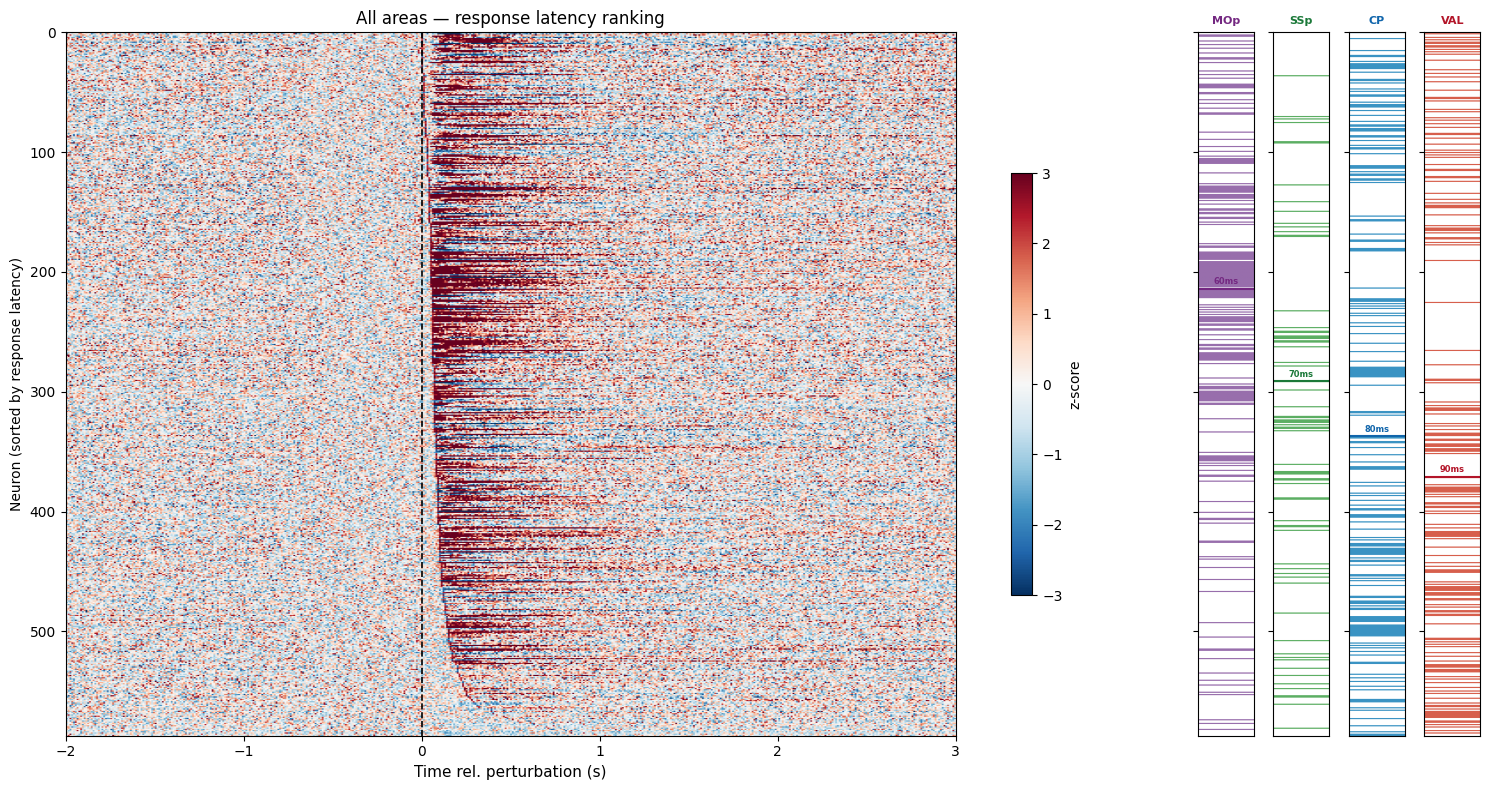

In [20]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(
    1, 5, figsize=(15, 8),
    gridspec_kw={'width_ratios': [20, 1, 1, 1, 1]},
    sharey=True
)
ax_heat = axes[0]

im = ax_heat.imshow(
    X_z[sort_order],
    aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3,
    extent=[time_bins[0], time_bins[-1], len(sort_order), 0]
)
ax_heat.axvline(0, color='k', linewidth=1.2, linestyle='--')
ax_heat.set_xlabel('Time rel. perturbation (s)', fontsize=11)
ax_heat.set_ylabel('Neuron (sorted by response latency)', fontsize=10)
ax_heat.set_title('All areas — response latency ranking', fontsize=12)
plt.colorbar(im, ax=ax_heat, label='z-score', shrink=0.6)

# Sorted latency in neuron-rank space (for drawing lines on strips)
latency_s_sorted = latency_s[sort_order]
labels_sorted    = labels[sort_order]
n_total = len(sort_order)

for ax_strip, a in zip(axes[1:], Params.areas):
    light_color = getattr(colors, f'{a}_light')
    area_color  = getattr(colors, a)
    membership  = (labels_sorted == a).astype(float).reshape(-1, 1)

    rgba = np.ones((n_total, 1, 4))
    rgba[:, 0, :3] = np.where(membership, light_color, 1.0)
    ax_strip.imshow(rgba, aspect='auto', extent=[0, 1, n_total, 0])
    ax_strip.set_xticks([])
    ax_strip.set_title(a, fontsize=8, color=area_color, fontweight='bold')

    # Median latency line
    median_lat = np.median(latency_s[labels == a])
    # Convert median latency (s) to neuron rank position
    median_rank = np.searchsorted(latency_s_sorted[labels_sorted == a], median_lat)
    # Get the actual neuron rank in the full sorted array
    area_ranks = np.where(labels_sorted == a)[0]
    median_neuron_rank = area_ranks[min(median_rank, len(area_ranks)-1)]

    ax_strip.axhline(median_neuron_rank, color=area_color, linewidth=1.5, linestyle='-')
    ax_strip.text(0.5, median_neuron_rank - 2, f'{median_lat*1000:.0f}ms',
                  ha='center', va='bottom', fontsize=6, color=area_color, fontweight='bold')

plt.tight_layout()
plt.show()

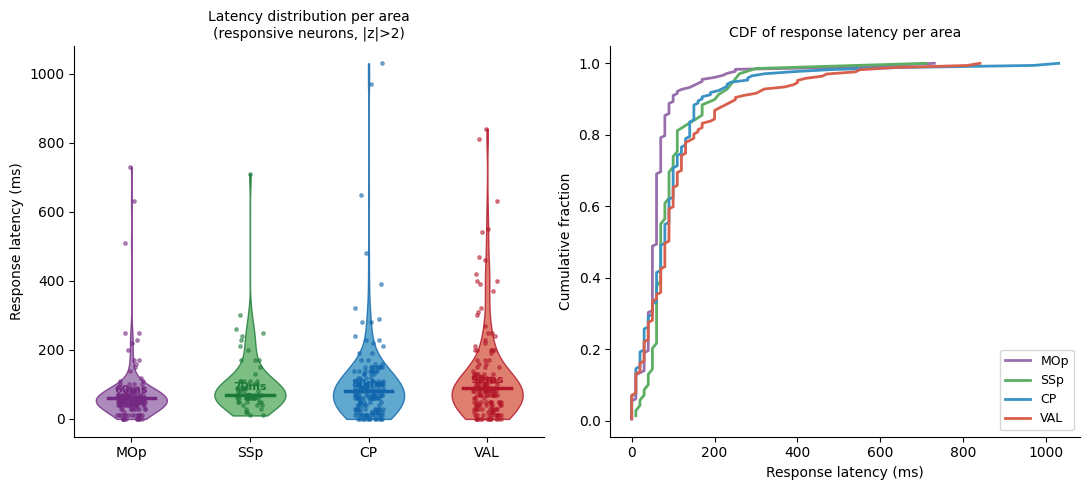

In [22]:
# Quantify latency differences: violin + individual points + median marker
# Only use responsive neurons (|z| > 2 was reached)
reached_threshold = np.array([np.any(np.abs(resp_z[i]) > 2) for i in range(len(resp_z))])

fig, (ax_vln, ax_cdf) = plt.subplots(1, 2, figsize=(11, 5))

# --- Left: violin per area (responsive neurons only) ---
for x_pos, a in enumerate(Params.areas):
    mask = (labels == a) & reached_threshold
    lats = latency_s[mask] * 1000  # ms
    color      = getattr(colors, a)
    light_color = getattr(colors, f'{a}_light')

    vp = ax_vln.violinplot(lats, positions=[x_pos], widths=0.6,
                           showmedians=False, showextrema=False)
    for body in vp['bodies']:
        body.set_facecolor(light_color)
        body.set_edgecolor(color)
        body.set_alpha(0.8)

    # Jittered points
    jitter = np.random.uniform(-0.12, 0.12, size=len(lats))
    ax_vln.scatter(x_pos + jitter, lats, s=6, color=color, alpha=0.5, zorder=3)

    # Median line
    med = np.median(lats)
    ax_vln.plot([x_pos - 0.2, x_pos + 0.2], [med, med],
                color=color, linewidth=2.5, zorder=4)
    ax_vln.text(x_pos, med + 8, f'{med:.0f}ms',
                ha='center', va='bottom', fontsize=8, color=color, fontweight='bold')

ax_vln.set_xticks(range(len(Params.areas)))
ax_vln.set_xticklabels(Params.areas, fontsize=10)
ax_vln.set_ylabel('Response latency (ms)', fontsize=10)
ax_vln.set_title('Latency distribution per area\n(responsive neurons, |z|>2)', fontsize=10)
ax_vln.spines['top'].set_visible(False)
ax_vln.spines['right'].set_visible(False)

# --- Right: CDF per area ---
for a in Params.areas:
    mask = (labels == a) & reached_threshold
    lats = np.sort(latency_s[mask] * 1000)
    cdf  = np.arange(1, len(lats)+1) / len(lats)
    ax_cdf.plot(lats, cdf, color=getattr(colors, f'{a}_light'), linewidth=2, label=a)

ax_cdf.set_xlabel('Response latency (ms)', fontsize=10)
ax_cdf.set_ylabel('Cumulative fraction', fontsize=10)
ax_cdf.set_title('CDF of response latency per area', fontsize=10)
ax_cdf.legend(fontsize=9)
ax_cdf.spines['top'].set_visible(False)
ax_cdf.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# All sessions

In [ ]:
sessions = [
    # 'M061_2025_03_04_10_00', 
    # 'M061_2025_03_05_14_00', 
    # 'M061_2025_03_06_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M063_2025_03_14_15_30', 
    # 'M062_2025_03_20_14_00',
    # 'M062_2025_03_21_14_00',
    # 'M078_2025_08_06_15_00',
    # 'M086_2025_12_10_15_00',
    'M103_2026_02_18_15_30',
    'M106_2026_02_25_15_00'

]
session_area_exclusions = {
    # 'M062_2025_03_20_14_00': ['VAL'],
    # 'M062_2025_03_21_14_00': ['SSp', 'CP'],
}

In [36]:

# --- Step 1: Load & preprocess all sessions into intermediate dict ---
# all_session_processed = {}  # {session: {'td': perturb_td_shuff, 'chance': float} or None}

for sess in tqdm(sessions, desc="Loading sessions"):
    print(f"\n{'='*60}\n{sess}\n{'='*60}")
    try:
        df_tr_s, dstrb_idx_s = dsp.load_and_process_session(sess, data_dir=data_dir)
        df_design_s = drop_unperturb_trials_modified(df_tr_s, dstrb_idx_s, thresh_val=-2)
        perturb_td_s = pyal.restrict_to_interval(
                    df_design_s, start_point_name='idx_sol_on', rel_start=-200, rel_end=300
                )
        all_session_processed[sess] = {'td': perturb_td_s}

    except Exception as e:
        import traceback
        print(f"  ERROR loading {sess}: {e}")
        traceback.print_exc()
        all_session_processed[sess] = None

print(f"\nLoaded {sum(v is not None for v in all_session_processed.values())}/{len(sessions)} sessions successfully.")


Loading sessions:   0%|          | 0/5 [00:00<?, ?it/s]


M061_2025_03_06_14_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)
Skipped 40 trials
Otsu immobility threshold: 2.9536
Dropped 48 of 333 rows (14.41%).
  threshold = -0.031  |  trials selected by threshold: 220  |  total trials kept: 217


Loading sessions:  20%|██        | 1/5 [00:51<03:25, 51.40s/it]

...


M106_2026_02_25_15_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)


Traceback (most recent call last):
  File "/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pandas/core/indexes/base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7081, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7089, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'right_knee'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/tmp/ipykernel_173437/3317815903.py", line 7, in <module>
    df_tr_s, dstrb_idx_s = dsp.load_and_process_session(sess, data_dir=data_dir)
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File

  ERROR loading M106_2026_02_25_15_00: 'right_knee'

Loaded 5/5 sessions successfully.


In [31]:
from scipy.stats import mannwhitneyu
from itertools import combinations

SOL_ON_BIN = 200

def compute_latencies(perturb_td, areas):
    """Returns dict {area: latency_ms array} for neurons that hit |z|>2."""
    bin_size = perturb_td['bin_size'].values[0]
    result = {}
    for a in areas:
        X_a = np.stack(perturb_td[f'{a}_spikes'].values)     # (n_trials, n_bins, n_neurons)
        tavg = X_a.mean(axis=0).T / bin_size                  # (n_neurons, n_bins)

        bl   = tavg[:, SOL_ON_BIN-60 : SOL_ON_BIN-10]
        resp = tavg[:, SOL_ON_BIN    : SOL_ON_BIN+150]

        bl_mu = bl.mean(axis=1, keepdims=True)
        bl_sd = bl.std(axis=1,  keepdims=True) + 1e-6
        resp_z = (resp - bl_mu) / bl_sd

        lats = []
        for i in range(resp_z.shape[0]):
            crosses = np.where(np.abs(resp_z[i]) > 2)[0]
            if len(crosses) > 0:
                lats.append(crosses[0] * bin_size * 1000)  # ms
        result[a] = np.array(lats)
    return result


# --- Collect latencies across sessions ---
pooled = {a: [] for a in Params.areas}

for sess, val in all_session_processed.items():
    if val is None:
        continue
    td = val['td']
    lats = compute_latencies(td, Params.areas)
    print(f"\n{sess}")
    for a in Params.areas:
        arr = lats[a]
        pooled[a].append(arr)
        if len(arr) > 0:
            print(f"  {a:4s}: n={len(arr):3d}  "
                  f"p10={np.percentile(arr,10):5.1f}ms  "
                  f"p25={np.percentile(arr,25):5.1f}ms  "
                  f"p50={np.percentile(arr,50):5.1f}ms")
        else:
            print(f"  {a:4s}: no responsive neurons")

# Concatenate across sessions
pooled = {a: np.concatenate(arrs) for a, arrs in pooled.items() if len(arrs) > 0}

# --- Summary across sessions ---
print(f"\n{'='*55}")
print("POOLED ACROSS SESSIONS")
print(f"{'='*55}")
for a in Params.areas:
    arr = pooled[a]
    print(f"  {a:4s}: n={len(arr):3d}  "
          f"p10={np.percentile(arr,10):5.1f}ms  "
          f"p25={np.percentile(arr,25):5.1f}ms  "
          f"p50={np.percentile(arr,50):5.1f}ms")

# --- Pairwise Mann-Whitney ---
print(f"\nPAIRWISE MANN-WHITNEY U (one-sided: row earlier than col)")
area_list = Params.areas
header = f"{'':6s}" + "".join(f"{a:>10s}" for a in area_list)
print(header)
for a1 in area_list:
    row = f"{a1:6s}"
    for a2 in area_list:
        if a1 == a2:
            row += f"{'---':>10s}"
        else:
            stat, p = mannwhitneyu(pooled[a1], pooled[a2], alternative='less')
            sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'ns')
            row += f"{f'p={p:.3f}{sig}':>10s}"
    print(row)


M061_2025_03_04_10_00
  MOp : n=206  p10= 20.0ms  p25= 40.0ms  p50= 60.0ms
  SSp : n= 59  p10= 18.0ms  p25= 60.0ms  p50= 80.0ms
  CP  : n=223  p10= 20.0ms  p25= 50.0ms  p50= 80.0ms
  VAL : n=239  p10= 20.0ms  p25= 50.0ms  p50= 80.0ms

M061_2025_03_05_14_00
  MOp : n=153  p10= 10.0ms  p25= 40.0ms  p50= 60.0ms
  SSp : n=118  p10= 20.0ms  p25= 50.0ms  p50= 70.0ms
  CP  : n=193  p10= 10.0ms  p25= 40.0ms  p50= 80.0ms
  VAL : n=219  p10= 10.0ms  p25= 45.0ms  p50= 90.0ms

POOLED ACROSS SESSIONS
  MOp : n=359  p10= 10.0ms  p25= 40.0ms  p50= 60.0ms
  SSp : n=177  p10= 20.0ms  p25= 50.0ms  p50= 70.0ms
  CP  : n=416  p10= 10.0ms  p25= 50.0ms  p50= 80.0ms
  VAL : n=458  p10= 10.0ms  p25= 50.0ms  p50= 80.0ms

PAIRWISE MANN-WHITNEY U (one-sided: row earlier than col)
             MOp       SSp        CP       VAL
MOp          --- p=0.000** p=0.000** p=0.000**
SSp    p=1.000ns       --- p=0.081ns p=0.085ns
CP     p=1.000ns p=0.919ns       --- p=0.657ns
VAL    p=1.000ns p=0.915ns p=0.343ns       ---


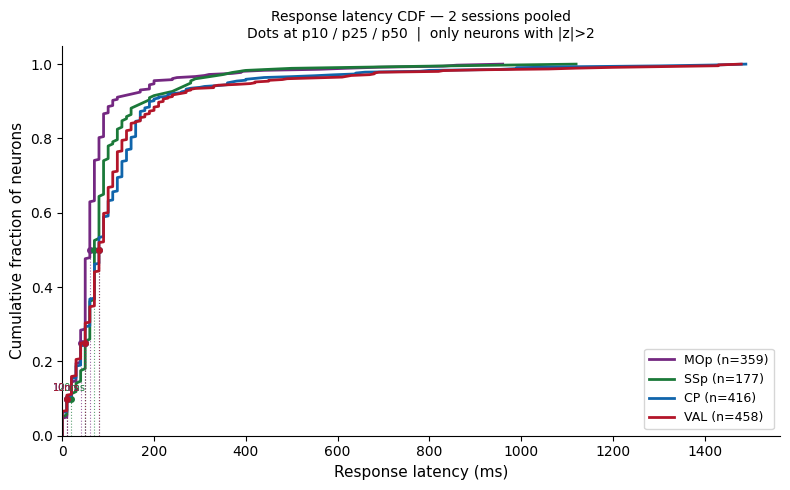

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))

percentiles = [10, 25, 50]

for a in Params.areas:
    arr = np.sort(pooled[a])
    cdf = np.arange(1, len(arr)+1) / len(arr)
    color = getattr(colors, a)
    light  = getattr(colors, f'{a}_light')

    ax.plot(arr, cdf, color=color, linewidth=2, label=f'{a} (n={len(arr)})')

    # Mark percentiles with vertical drops
    for pct in percentiles:
        val = np.percentile(arr, pct)
        cdf_val = pct / 100
        ax.plot([val, val], [0, cdf_val], color=color, linewidth=0.8,
                linestyle=':', alpha=0.7)
        ax.plot(val, cdf_val, 'o', color=color, markersize=4)
        if pct == 10:  # only annotate p10 to avoid clutter
            ax.text(val, cdf_val + 0.02, f'{val:.0f}ms',
                    fontsize=7, color=color, ha='center')

ax.set_xlabel('Response latency (ms)', fontsize=11)
ax.set_ylabel('Cumulative fraction of neurons', fontsize=11)
ax.set_title(
    f'Response latency CDF — {len(sessions)} sessions pooled\n'
    f'Dots at p10 / p25 / p50  |  only neurons with |z|>2',
    fontsize=10
)
ax.legend(fontsize=9)
ax.set_xlim(left=0)
ax.set_ylim(0, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

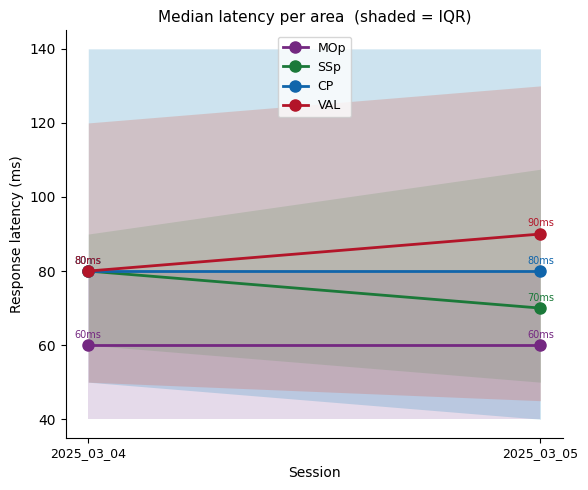

In [34]:
valid_sessions = [s for s, v in all_session_processed.items() if v is not None]

session_medians = {a: [] for a in Params.areas}
session_p25     = {a: [] for a in Params.areas}
session_p75     = {a: [] for a in Params.areas}

for sess in valid_sessions:
    td = all_session_processed[sess]['td']
    lats = compute_latencies(td, Params.areas)
    for a in Params.areas:
        arr = lats[a]
        if len(arr) > 0:
            session_medians[a].append(np.median(arr))
            session_p25[a].append(np.percentile(arr, 25))
            session_p75[a].append(np.percentile(arr, 75))
        else:
            session_medians[a].append(np.nan)
            session_p25[a].append(np.nan)
            session_p75[a].append(np.nan)

fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(len(valid_sessions))
x_labels = [s[5:15] for s in valid_sessions]

for a in Params.areas:
    color      = getattr(colors, a)
    light_color = getattr(colors, f'{a}_light')
    med = np.array(session_medians[a])
    p25 = np.array(session_p25[a])
    p75 = np.array(session_p75[a])

    # IQR shaded band
    ax.fill_between(x, p25, p75, alpha=0.25, color=light_color, linewidth=0)

    # Median line + dots
    ax.plot(x, med, 'o-', color=color, linewidth=2, markersize=8, label=a, zorder=3)

    # Annotate median only
    for xi, v in zip(x, med):
        if not np.isnan(v):
            ax.text(xi, v + 1.5, f'{v:.0f}ms', ha='center', va='bottom',
                    fontsize=7, color=color)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel('Response latency (ms)', fontsize=10)
ax.set_xlabel('Session', fontsize=10)
ax.set_title('Median latency per area  (shaded = IQR)', fontsize=11)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()